In [1]:
#Descriptive Analytics for Numerical Columns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('sales_data_with_discounts.csv')
df

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103758
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [4]:
print(df[['Volume','Avg Price','Total Sales Value','Discount Rate (%)',
    'Discount Rate (%)','Net Sales Value']])

     Volume  Avg Price  Total Sales Value  Discount Rate (%)  \
0        15      12100             181500          11.654820   
1        10      10100             101000          11.560498   
2         7      16100             112700           9.456886   
3         6      20100             120600           6.935385   
4         3       8100              24300          17.995663   
..      ...        ...                ...                ...   
445       2       1300               2600          15.475687   
446       6       2600              15600          17.057027   
447       2       1600               3200          18.965550   
448       3       1900               5700          16.793014   
449       1       3100               3100          15.333300   

     Discount Rate (%)  Net Sales Value  
0            11.654820    160346.501180  
1            11.560498     89323.897039  
2             9.456886    102042.089843  
3             6.935385    112235.925298  
4            17.99566

In [5]:
for i in df.select_dtypes(include=['int','float']).columns:
    print(f"Numerical colunms are:{i}")

Numerical colunms are:Volume
Numerical colunms are:Avg Price
Numerical colunms are:Total Sales Value
Numerical colunms are:Discount Rate (%)
Numerical colunms are:Discount Amount
Numerical colunms are:Net Sales Value


In [6]:
df.describe(include="O")

,Date,Day,SKU,City,BU,Brand,Model
count,450,450,450,450,450,450,450
unique,15,7,30,1,3,9,30
top,01-04-2021,Thursday,M01,C,Mobiles,Jeera,RU-10
freq,30,90,15,450,150,90,15


In [7]:
df.describe(include="all")

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450,450,450,450,450.000000,450,450,450,450.000000,450.000000,450.000000,450.000000,450.000000
unique,15,7,30,1,NaN,3,9,30,NaN,NaN,NaN,NaN,NaN
top,01-04-2021,Thursday,M01,C,NaN,Mobiles,Jeera,RU-10,NaN,NaN,NaN,NaN,NaN
freq,30,90,15,450,NaN,150,90,15,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,5.066667,NaN,NaN,NaN,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,NaN,NaN,NaN,NaN,4.231602,NaN,NaN,NaN,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,290.000000,400.000000,5.007822,69.177942,326.974801
25%,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,10100.000000,53200.000000,18.114718,5316.495427,47847.912852


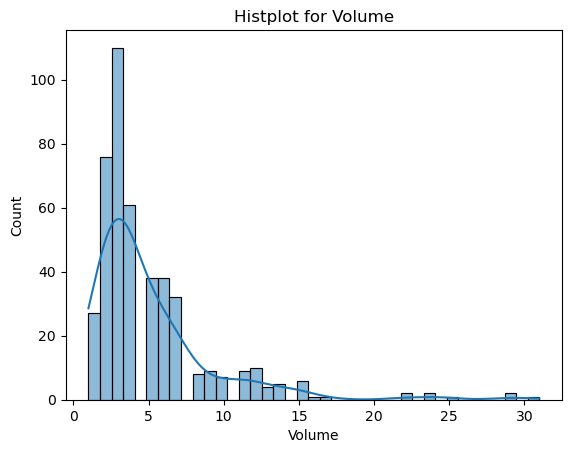

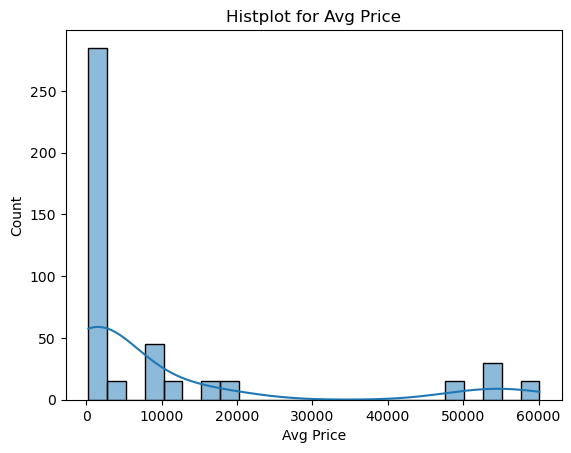

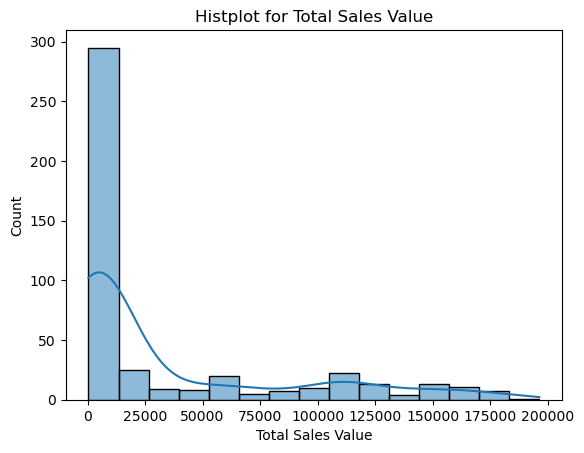

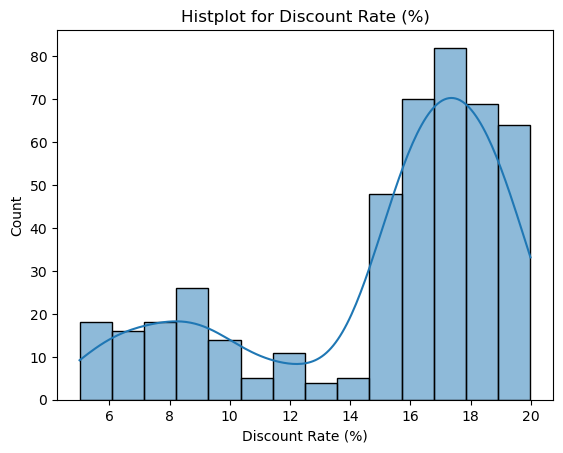

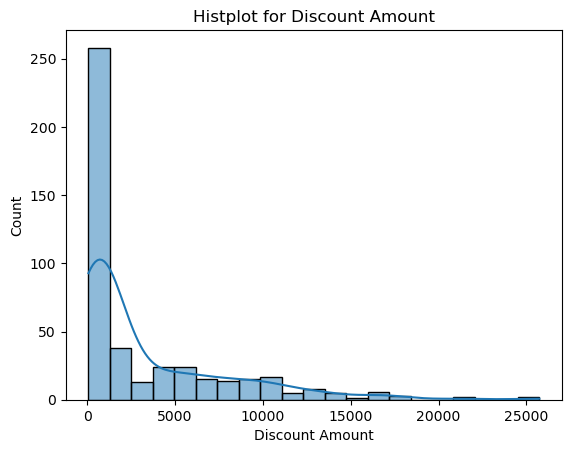

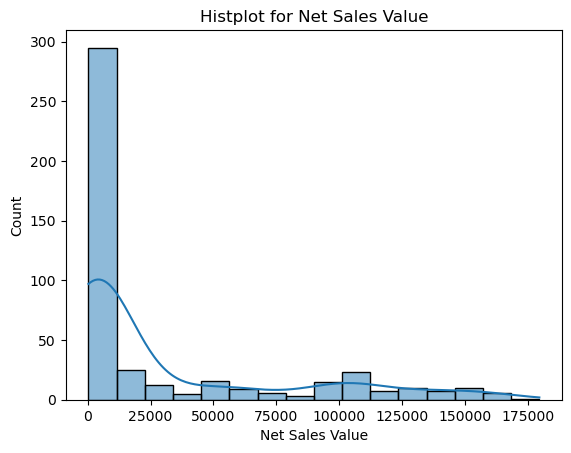

In [8]:
#Data Visualization:
for col in df.select_dtypes(include=['int','float']).columns:
    sns.histplot(df[col],kde=True)
    plt.title(f"Histplot for {col}")
    plt.show()

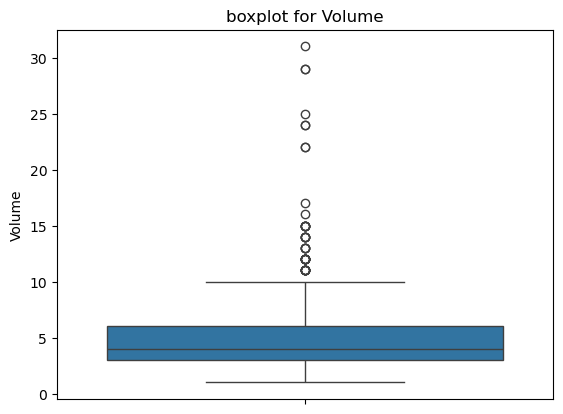

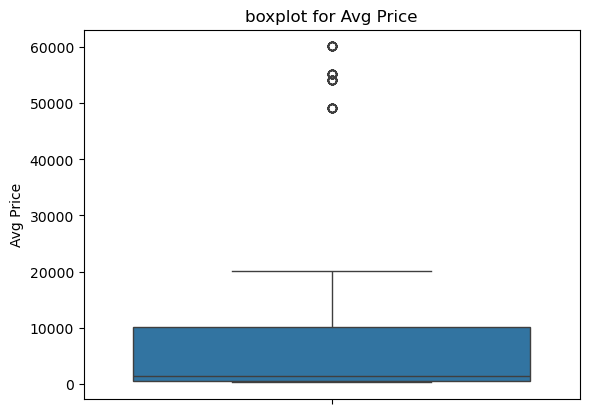

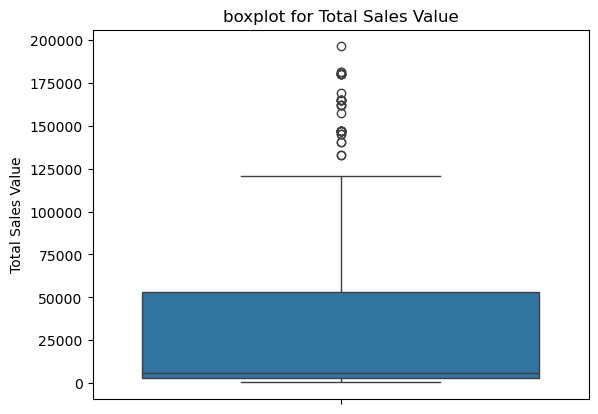

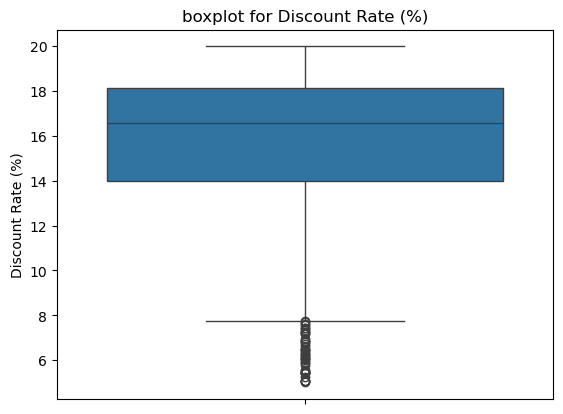

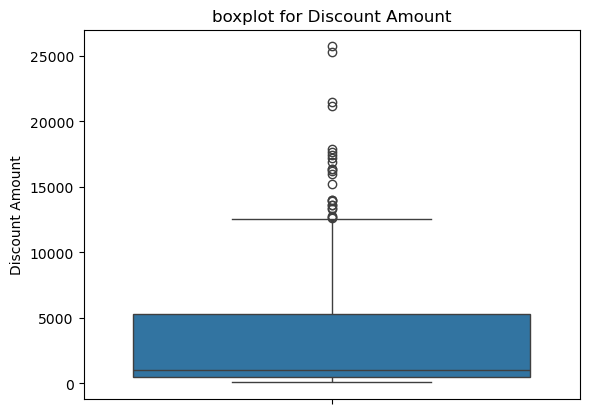

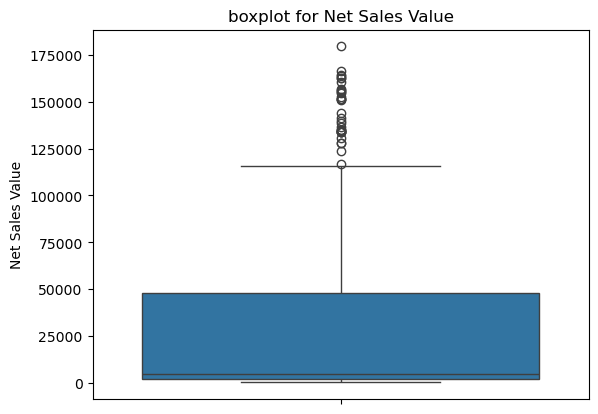

In [9]:
for col in df.select_dtypes(include=['int',float]).columns:
    sns.boxplot(df[col])
    plt.title(f"boxplot for {col}")
    plt.show()

In [10]:
#The above boxplot shows there are outliers in  the dataset.
#The dotted structure at above and below of groph are extreme values.
#outlier capping
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.2*iqr
    upper=q3+1.2*iqr
    df[i]=df[i].clip(lower,upper)

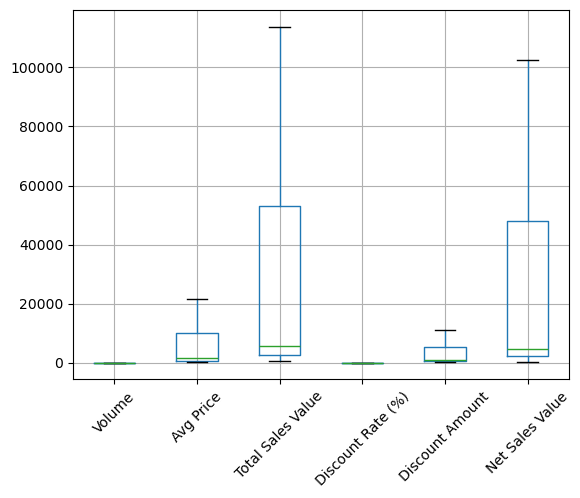

In [11]:
df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    float64
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(4), int64(2), object(7)
memory usage: 45.8+ KB


In [13]:
for i in df.select_dtypes(include=['object']).columns:
    print(f"Categorical colunms are:{i}")

Categorical colunms are:Date
Categorical colunms are:Day
Categorical colunms are:SKU
Categorical colunms are:City
Categorical colunms are:BU
Categorical colunms are:Brand
Categorical colunms are:Model


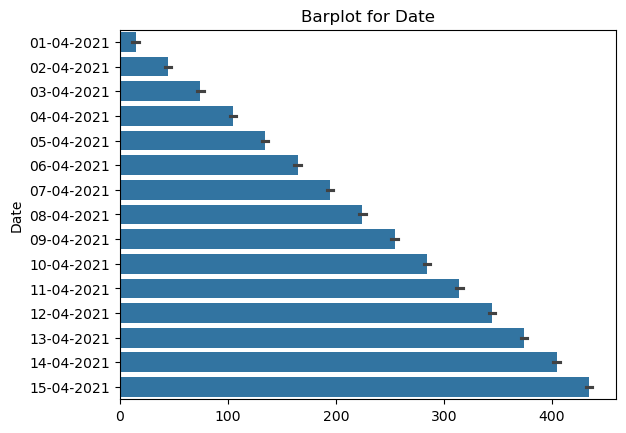

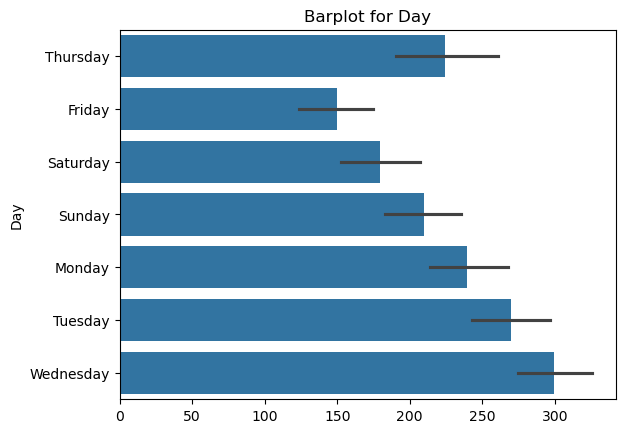

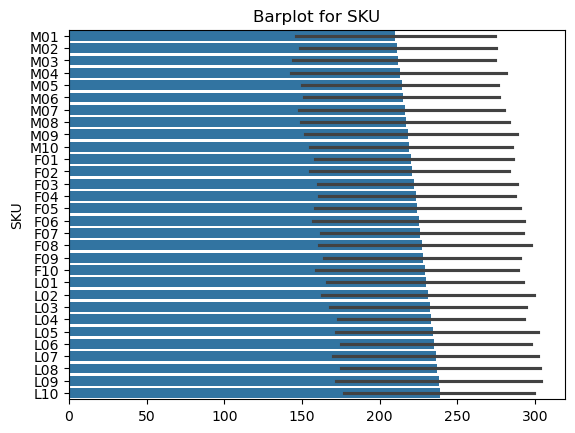

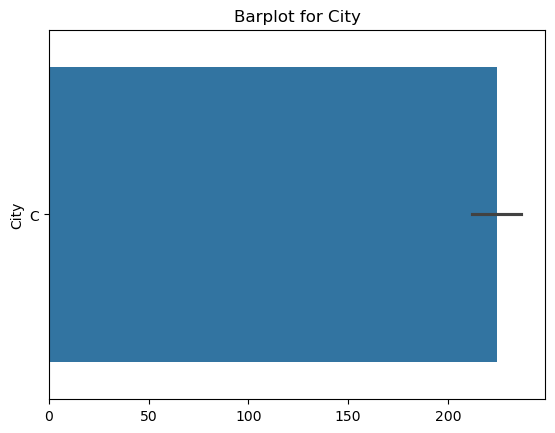

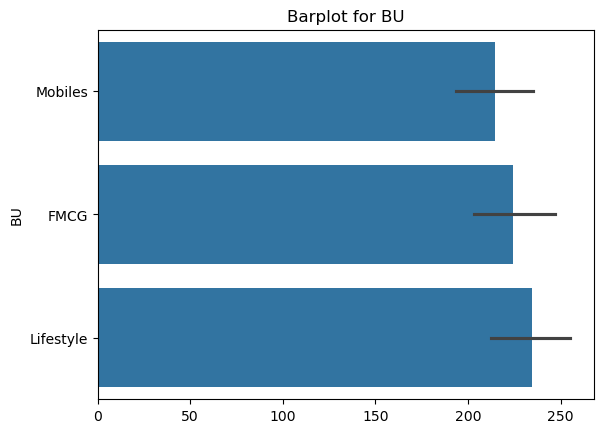

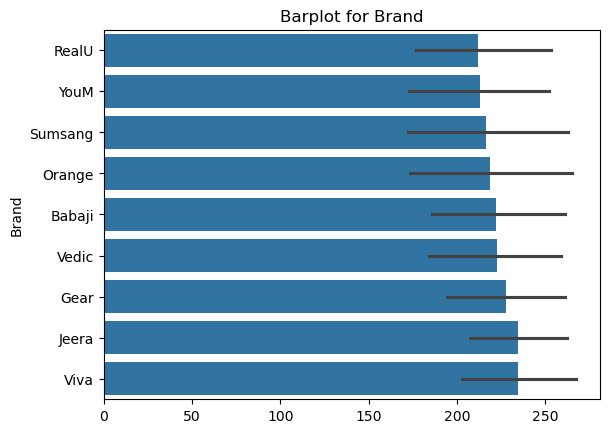

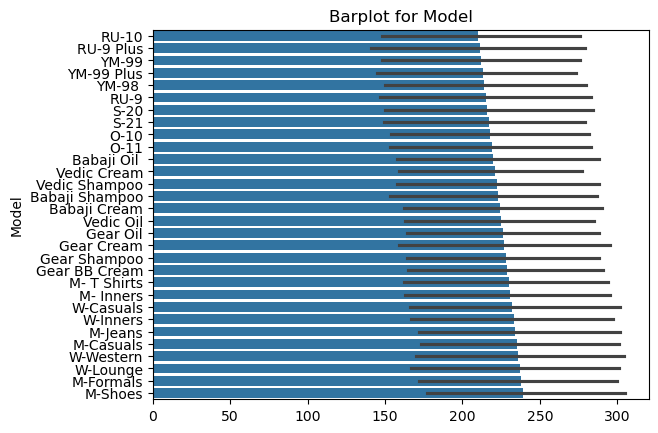

In [14]:
for col in df.select_dtypes(include=['object']).columns:
    sns.barplot(df[col])
    plt.title(f"Barplot for {col}")
    plt.show()

Conclusion:
Key findings:
   The summary of the given dataset is that it shows various aspects can be said as features
used in daily life such as mobile phone,brands and etc and their value and discounts related to the sales there is more discount on thursday and recorded low(~avg) on friday but gradually increases day by day.
  And it mainly indicates that day by day the sales are increasing for every type of things
and shows the evolution of things in given aspects and shows that there are variety of choices from which a person can select and recpectively followed by the sales and discounts on high demand things.